# Exploratory Data Analysis and Baseline Modeling

This notebook covers the EDA and Baseline Modeling requirements for the project check-in. It uses **Polars** for efficient data wrangling as part of the course application!

In [10]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")

# Load the dataset generated by data_collection.py using Polars
file_path = os.path.join("data", "merged_financial_sentiment_data.csv")

try:
    df = pl.read_csv(file_path)
    
    # Convert to datetime native using the exact format string for your data
    df = df.with_columns(
        pl.col('Timestamp').str.to_datetime(format="%Y-%m-%dT%H:%M:%S%.f%z")
    )
    
    display(df.head())
    
except FileNotFoundError:
    print(f"File '{file_path}' not found! Please run data_collection.py first.")

Ticker,Timestamp,Text,Sentiment,Post_Count,Open,High,Low,Close,Volume
str,"datetime[μs, UTC]",str,f64,i64,f64,f64,f64,f64,i64
"""$AAPL""",2025-07-07 23:00:00 UTC,"""BREAKING: Apple’s, $AAPL, top …",-0.220868,2,210.130005,210.490005,208.449997,209.279999,9381795
"""$AAPL""",2025-07-07 23:00:00 UTC,"""🔴 Importance: 65/100 #news #To…",-0.440318,2,210.130005,210.490005,208.449997,209.279999,9381795
"""$AAPL""",2025-07-08 00:00:00 UTC,"""What do you think #investors? …",0.150104,2,210.130005,210.490005,208.449997,209.279999,9381795
"""$AAPL""",2025-07-08 00:00:00 UTC,"""Lemme guess... you bought AAPL…",0.012221,2,210.130005,210.490005,208.449997,209.279999,9381795
"""$AAPL""",2025-07-08 02:00:00 UTC,"""$AAPL Support / Resistance Lev…",0.027583,1,210.130005,210.490005,208.449997,209.279999,9381795


## 1. Summary Statistics & Data Imbalances

In [11]:
display(df.describe())

# Identifying nulls and imbalances using Polars natively
print("\n--- Null Value Counts ---")
print(df.null_count())

print("\n--- Ticker Value Counts (Potential Sampling Imbalance) ---")
print(df['Ticker'].value_counts())

statistic,Ticker,Timestamp,Text,Sentiment,Post_Count,Open,High,Low,Close,Volume
str,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""194891""","""194891""","""194891""",194891.0,194891.0,194891.0,194891.0,194891.0,194891.0,194891.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,"""2026-01-03 17:40:51.050074+00:…",null,-0.009414,19.849203,258.082972,259.158783,257.052847,258.193248,4.9756e6
"""std""",null,null,null,0.350317,31.087351,210.644967,211.087442,210.122954,210.62411,7.1733e6
"""min""","""$AAPL""","""2009-01-02 03:00:00+00:00""","""""",-0.969634,1.0,0.93365,0.948,0.93,0.9337,52309.0
"""25%""",null,"""2025-12-03 14:00:00+00:00""",null,-0.049075,2.0,90.784203,91.240097,90.350502,90.800003,1.365156e6
"""50%""",null,"""2026-03-17 04:00:00+00:00""",null,0.010218,7.0,207.485001,208.5,206.281998,207.410004,2.989546e6
"""75%""",null,"""2026-04-21 07:00:00+00:00""",null,0.071893,26.0,370.850006,372.450012,368.820007,370.160004,6.081555e6
"""max""","""$TSLA""","""2026-04-28 23:00:00+00:00""","""🫶🏻🩷 I spy a kirby""",0.947921,357.0,715.130005,715.630005,714.880005,715.159973,2.29986282e8



--- Null Value Counts ---
shape: (1, 10)
┌────────┬───────────┬──────┬───────────┬───┬──────┬─────┬───────┬────────┐
│ Ticker ┆ Timestamp ┆ Text ┆ Sentiment ┆ … ┆ High ┆ Low ┆ Close ┆ Volume │
│ ---    ┆ ---       ┆ ---  ┆ ---       ┆   ┆ ---  ┆ --- ┆ ---   ┆ ---    │
│ u32    ┆ u32       ┆ u32  ┆ u32       ┆   ┆ u32  ┆ u32 ┆ u32   ┆ u32    │
╞════════╪═══════════╪══════╪═══════════╪═══╪══════╪═════╪═══════╪════════╡
│ 0      ┆ 0         ┆ 0    ┆ 0         ┆ … ┆ 0    ┆ 0   ┆ 0     ┆ 0      │
└────────┴───────────┴──────┴───────────┴───┴──────┴─────┴───────┴────────┘

--- Ticker Value Counts (Potential Sampling Imbalance) ---
shape: (23, 2)
┌────────┬───────┐
│ Ticker ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ $SPY   ┆ 9730  │
│ $AMZN  ┆ 9837  │
│ $RDDT  ┆ 1528  │
│ $GOOGL ┆ 9159  │
│ $AMD   ┆ 9730  │
│ …      ┆ …     │
│ $PLTR  ┆ 9311  │
│ $QQQ   ┆ 9551  │
│ $MSFT  ┆ 9564  │
│ $AMC   ┆ 9823  │
│ $COIN  ┆ 9457  │
└────────┴───────┘


## 2. Visualizations

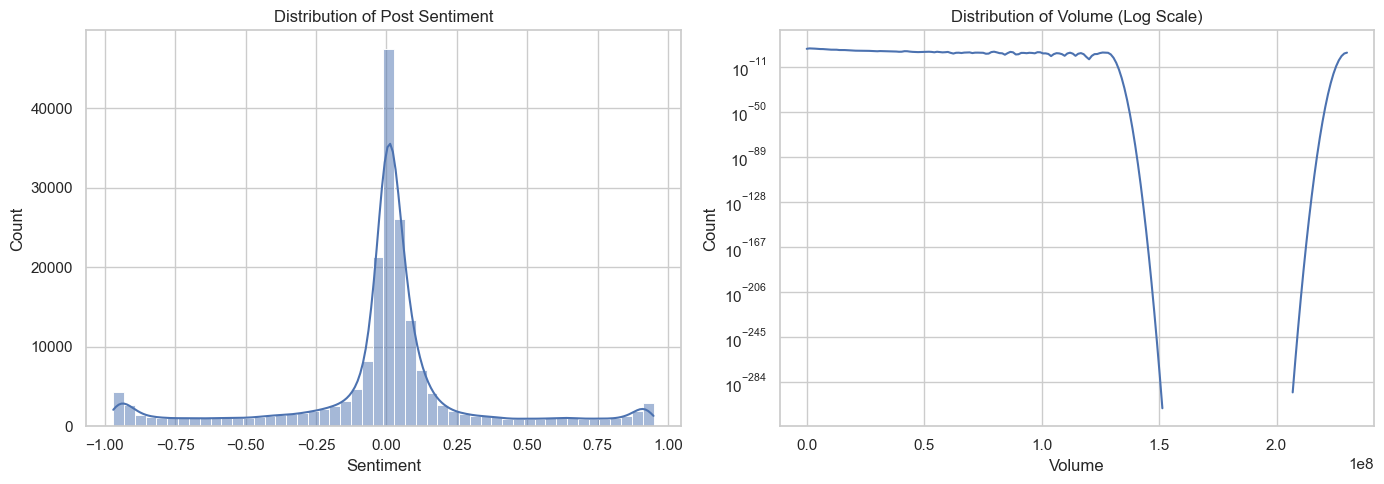

In [12]:
# Seaborn operates primarily on Pandas dataframes, so we safely cast to pandas momentarily for plotting
pdf = df.to_pandas()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(pdf['Sentiment'], bins=50, ax=ax[0], kde=True)
ax[0].set_title('Distribution of Post Sentiment')

sns.histplot(pdf['Volume'], bins=50, ax=ax[1], kde=True, log_scale=(False, True))
ax[1].set_title('Distribution of Volume (Log Scale)')

plt.tight_layout()
plt.show()

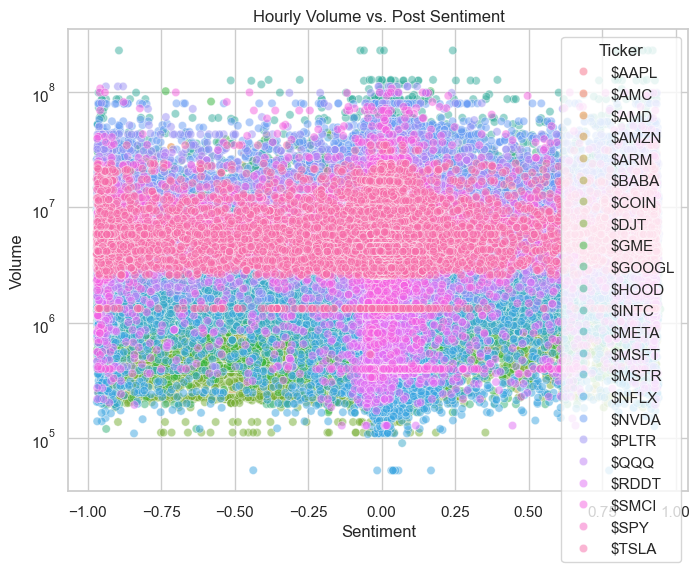

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pdf, x='Sentiment', y='Volume', hue='Ticker', alpha=0.5)
plt.title('Hourly Volume vs. Post Sentiment')
plt.yscale('log') 
plt.show()

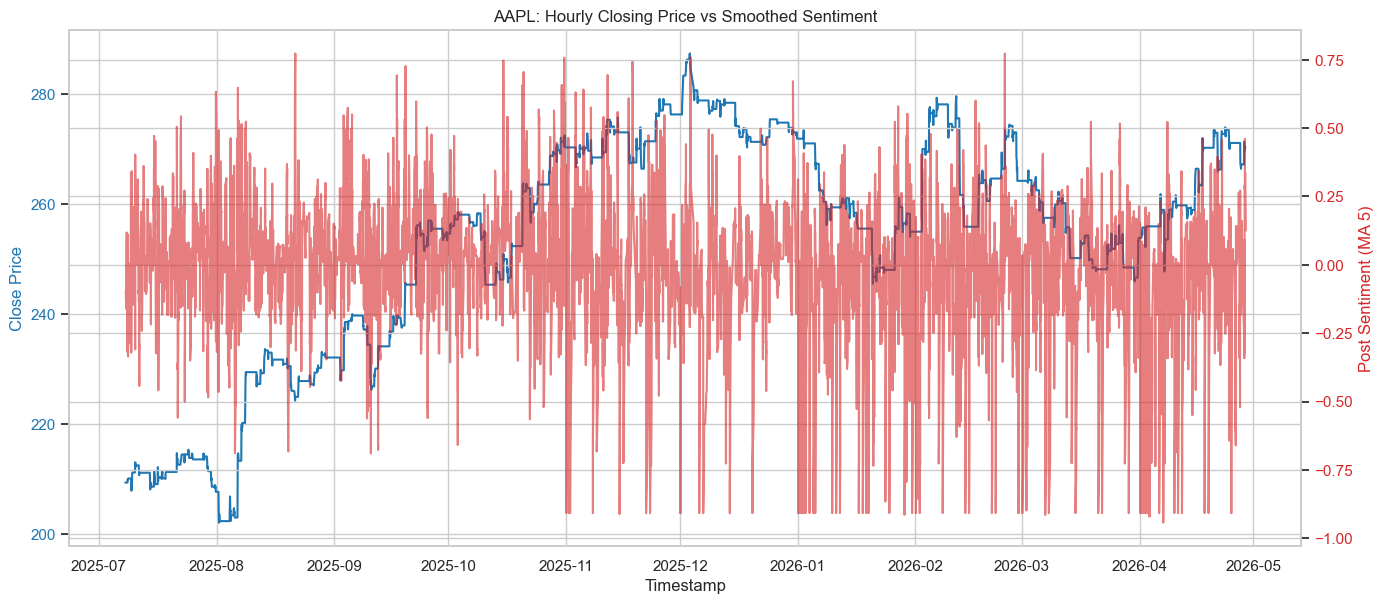

In [14]:
# Polars query to sort and filter for a single ticker to plot time series
ticker_df = df.filter(pl.col('Ticker') == '$AAPL').sort('Timestamp')

if not ticker_df.is_empty():
    # Calculate 5-period moving average using Polars rolling functions to smooth noise
    ticker_df = ticker_df.with_columns(
        pl.col('Sentiment').rolling_mean(window_size=5).alias('Sentiment_MA_5')
    )
    
    ticker_pdf = ticker_df.to_pandas()
    
    fig, ax1 = plt.subplots(figsize=(14, 6))
    color = 'tab:blue'
    ax1.set_xlabel('Timestamp')
    ax1.set_ylabel('Close Price', color=color)
    ax1.plot(ticker_pdf['Timestamp'], ticker_pdf['Close'], color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Post Sentiment (MA 5)', color=color)
    ax2.plot(ticker_pdf['Timestamp'], ticker_pdf['Sentiment_MA_5'], color=color, alpha=0.6)
    ax2.tick_params(axis='y', labelcolor=color)
    
    fig.tight_layout()  
    plt.title('AAPL: Hourly Closing Price vs Smoothed Sentiment')
    plt.show()

### EDA Findings & Informing the Modeling Phase

**1. Sentiment Distributions**: The social sentiment distribution usually exhibits a heavy peak near $0.0$ (neutral posts).
**2. Volume Skewness**: Stock volume is highly right-skewed. Heavy volume spikes coincide with major events/retail squeezes. Standard scaling or log transformations on `Volume` is critical before Logistic Regression.
**3. Missing Data / Night Truncation**: Weekends or out-of-hours stock trading periods naturally introduce gaps. The inner join structure correctly handles this.

## 3. Baseline Modeling
We define our target variable conceptually as: **Next-Period Price Direction (1 for Up, 0 for Down)** to mimic the proposal's classification predictive goal over our hourly granularity dataset.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Create Target Variable using Polars Window functions
df = df.sort(['Ticker', 'Timestamp'])

# Shift -1 per ticker to get Next Close. Polars `shift(-1)` moves data up.
df = df.with_columns(
    pl.col('Close').shift(-1).over('Ticker').alias('Next_Close')
)
df = df.drop_nulls(subset=['Next_Close'])

# Target Generation (Binary: 1 for upward movement, 0 for downward/flat)
df = df.with_columns(
    (pl.col('Next_Close') > pl.col('Close')).cast(pl.Int32).alias('Target_Direction')
)

print("Target Class Imbalance check:")
print(df['Target_Direction'].value_counts())

Target Class Imbalance check:
shape: (2, 2)
┌──────────────────┬────────┐
│ Target_Direction ┆ count  │
│ ---              ┆ ---    │
│ i32              ┆ u32    │
╞══════════════════╪════════╡
│ 1                ┆ 7835   │
│ 0                ┆ 187033 │
└──────────────────┴────────┘


In [16]:
# Select Features and strict train-test split 
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Sentiment', 'Post_Count']

# Scikit-Learn expects numpy arrays or pandas DFs.
# Polars integrates tightly via .to_pandas() / .to_numpy() 
X = df.select(features).to_pandas()
y = df.select('Target_Direction').to_numpy().ravel()

# NO SHUFFLING to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (155894, 7)
Testing set shape: (38974, 7)


In [17]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Baseline Logistic Regression Model
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

--- Baseline Logistic Regression Results ---

              precision    recall  f1-score   support

           0       0.99      0.38      0.54     36980
           1       0.07      0.93      0.14      1994

    accuracy                           0.40     38974
   macro avg       0.53      0.65      0.34     38974
weighted avg       0.94      0.40      0.52     38974

ROC-AUC Score: 0.7393425137500114


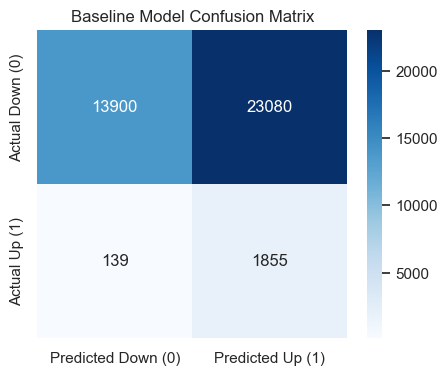

In [18]:
# Predictions & Evaluation
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("--- Baseline Logistic Regression Results ---\n")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Visualizing Performance
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Down (0)', 'Predicted Up (1)'], 
            yticklabels=['Actual Down (0)', 'Actual Up (1)'])
plt.title('Baseline Model Confusion Matrix')
plt.show()